<a href="https://colab.research.google.com/github/andrew52522/AB_test_CUPED_course_worK/blob/main/%D0%BA%D1%83%D1%80%D1%87%D0%B0%D1%81_%D1%87%D0%B5%D1%80%D0%BD%D0%BE%D0%B2%D0%B8%D0%BA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Adjust the path to your CSV file as needed
csv_path = '/content/drive/MyDrive/Cuped_курсач/dataset_back.csv'
try:
    df = pd.read_csv(csv_path)
    print(f"Successfully loaded CSV from {csv_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: CSV file not found at {csv_path}. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Successfully loaded CSV from /content/drive/MyDrive/Cuped_курсач/dataset_back.csv


,nfu_flg,orig_cost_sum,life_1_day_flg,life_32_day_flg,channel_desc,flow_strategy_code,pdt,el,ms,cs,...,app_xsell_total_sale_flg,email_cnt_all,email_cnt_1,email_open_flg_sum,email_open_flg_sum_1,email_delivery_flg_sum,email_delivery_flg_sum_1,email_click_cnt_sum,email_click_cnt_sum_1,email_open_to_delivery_sum_ratio
0,1,0.00,0,0,МБ,NCD,0,-1,-1,0,...,0,19,11,0,0,7,3,0,0,0.000000
1,0,0.00,0,0,МБ,DAC,0,-1,-1,0,...,1,119,19,2,1,119,19,0,0,0.016807
2,1,0.00,0,0,МБ,DAC,0,0,1,0,...,0,6,1,5,1,6,1,0,0,0.833333
3,0,0.00,1,1,МБ,DAC,0,3,0,0,...,0,1,0,0,0,0,0,0,0,0.000000
4,0,1021.11,0,0,Web,FST,0,-1,-1,0,...,0,3,3,0,0,3,3,0,0,0.000000


In [ ]:
df.shape


(83208, 357)

In [ ]:
df_back = df

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.tree import DecisionTreeRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# =======================================================
# 1. ЗАГРУЗКА И ПРЕДОБРАБОТКА
# =======================================================
# df_back = pd.read_csv('Dataset_back.csv') # раскомментируй для загрузки
# Для примера предполагаем, что df_back уже в памяти

# Предобработка: замена -1 и NaN на 0 (согласно ТЗ)
df_back = df_back.replace(-1, 0).fillna(0)

# Таргет и исключения
target = 'orig_cost_sum'
# СТРОГО ИСКЛЮЧАЕМ ДРУГИЕ ТАРГЕТЫ И АЙДИШНИКИ (Защита от Data Leakage!)
exclude_cols = [target, 'life_1_day_flg', 'life_32_day_flg', 'client_id']

# Фичи-кандидаты для страт (категориальные флаги и приложения)
# Впиши сюда все свои категориальные фичи
strata_candidates = ['app_nm', 'nfu_flg']
# Если 'app_nm' нет, оставь только те, что есть в датасете

# =======================================================
# 2. TREE-BASED СТРАТИФИКАЦИЯ (ГЛОБАЛЬНО)
# =======================================================
print("ЭТАП 1: Создание нелинейных страт с помощью Дерева Решений...")

# Берем только существующие в датасете категориальные колонки
valid_strata_cols = [col for col in strata_candidates if col in df_back.columns]

if valid_strata_cols:
    X_strata = pd.get_dummies(df_back[valid_strata_cols], drop_first=True)
    # Ограничиваем дерево 4-6 листьями, чтобы страты были крупными и стабильными
    tree = DecisionTreeRegressor(max_leaf_nodes=5, random_state=42)
    tree.fit(X_strata, df_back[target])
    df_back['strata_id'] = tree.apply(X_strata)
else:
    # Если категориальных колонок нет, делаем 1 общую страту (fallback)
    df_back['strata_id'] = 1

print(f"Пользователи разбиты на {df_back['strata_id'].nunique()} страт(ы).")
print(df_back['strata_id'].value_counts())

# Создаем пустую колонку для новой метрики
df_back['orig_cost_sum_cuped'] = np.nan

# Все числовые фичи, доступные для анализа
all_numeric_features = [col for col in df_back.select_dtypes(include=np.number).columns
                        if col not in exclude_cols + ['strata_id']]

# =======================================================
# 3. ИСПРАВЛЕННЫЙ ЛОКАЛЬНЫЙ ГИБРИДНЫЙ MULTI-CUPED
# =======================================================
print("\nЭТАП 2: Локальный отбор ковариат, PCA и OLS внутри каждой страты...")

for strata_val in df_back['strata_id'].unique():
    idx = df_back['strata_id'] == strata_val
    df_strata = df_back[idx].copy()

    n_samples = len(df_strata)
    if n_samples < 50:
        df_back.loc[idx, 'orig_cost_sum_cuped'] = df_strata[target]
        continue

    print(f"  -> Обработка Страты {strata_val} (размер: {n_samples})")

    # 1. Считаем корреляции и берем ТОП-5
    # Обязательно заполняем NaN в корреляциях нулями (возникают при константах)
    correlations = df_strata[all_numeric_features + [target]].corr()[target].drop(target).fillna(0)
    top_5_covariates = correlations.abs().nlargest(5).index.tolist()

    # 2. Готовим хвост для PCA
    remaining_features = [col for col in all_numeric_features if col not in top_5_covariates]
    X_pca_input = df_strata[remaining_features]

    # !!! КЛЮЧЕВОЕ ИСПРАВЛЕНИЕ !!!
    # Удаляем колонки, которые внутри ЭТОЙ страты являются константами (std == 0)
    # Это предотвратит появление NaN при масштабировании
    non_constant_cols = X_pca_input.columns[X_pca_input.std() > 0].tolist()
    X_pca_input = X_pca_input[non_constant_cols]

    if len(non_constant_cols) > 0:
        # Масштабируем только неконстантные колонки
        scaler = StandardScaler()
        X_rem_scaled = scaler.fit_transform(X_pca_input)

        # На всякий случай еще раз страхуемся от NaN после скейлера
        X_rem_scaled = np.nan_to_num(X_rem_scaled)

        # PCA
        n_comp = min(5, len(non_constant_cols), n_samples - 1)
        pca = PCA(n_components=n_comp, random_state=42)
        pca_components = pca.fit_transform(X_rem_scaled)

        pca_cols = []
        for i in range(n_comp):
            col_name = f'pca_comp_{i+1}'
            df_strata[col_name] = pca_components[:, i]
            pca_cols.append(col_name)
    else:
        pca_cols = []
        print(f"     [!] В страте {strata_val} нет вариативных признаков для PCA")

    # 3. OLS (Multi-CUPED)
    # Собираем все доступные фичи (топы + то, что выжали из PCA)
    final_covariates = top_5_covariates + pca_cols

    # Удаляем из финального списка те фичи, которые всё равно остались константами
    # (OLS упадет, если будет константа в предикторах)
    final_covariates = [c for c in final_covariates if df_strata[c].std() > 0]

    X_multi = sm.add_constant(df_strata[final_covariates])
    y_target = df_strata[target]

    # Обучаем модель
    ols_model = sm.OLS(y_target, X_multi).fit()

    # Предсказания (Супер-ковариата)
    super_covariate = ols_model.predict(X_multi)

    # CUPED: Y_cuped = Y - Y_hat + mean(Y)
    mean_target = y_target.mean()
    cuped_values = y_target - super_covariate + mean_target

    # Записываем результат
    df_back.loc[idx, 'orig_cost_sum_cuped'] = cuped_values

# =======================================================
# 4. ОЦЕНКА (БЕЗ ИЗМЕНЕНИЙ)
# =======================================================
print("\nЭТАП 3: Оценка эффективности гибридного пайплайна...")

var_original = df_back[target].var()
var_cuped = df_back['orig_cost_sum_cuped'].var()
variance_reduction = (1 - var_cuped / var_original) * 100

print(f"Исходная дисперсия (var_original): {var_original:.6f}")
print(f"Дисперсия после CUPED (var_cuped): {var_cuped:.6f}")
print(f"🔥 Итоговое снижение дисперсии: {variance_reduction:.2f}% 🔥")

# Проверка на несмещенность (средние значения должны совпасть)
mean_orig = df_back[target].mean()
mean_cuped = df_back['orig_cost_sum_cuped'].mean()
print(f"Среднее ДО: {mean_orig:.4f} | Среднее ПОСЛЕ: {mean_cuped:.4f} (Разница: {abs(mean_orig - mean_cuped):.4e})")

ЭТАП 1: Создание нелинейных страт с помощью Дерева Решений...
Пользователи разбиты на 2 страт(ы).
strata_id
1    47795
2    35413
Name: count, dtype: int64

ЭТАП 2: Локальный отбор ковариат, PCA и OLS внутри каждой страты...
  -> Обработка Страты 2 (размер: 35413)
  -> Обработка Страты 1 (размер: 47795)

ЭТАП 3: Оценка эффективности гибридного пайплайна...
Исходная дисперсия (var_original): 131555.660118
Дисперсия после CUPED (var_cuped): 125280.004752
🔥 Итоговое снижение дисперсии: 4.77% 🔥
Среднее ДО: 112.3721 | Среднее ПОСЛЕ: 112.3721 (Разница: 1.3500e-12)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Устанавливаем красивый стиль для графиков
sns.set_theme(style="whitegrid", palette="muted")


# 1. Замена искусственных -1 на 0
df_back = df_back.replace(-1, 0)

# 2. Обработка пропусков (Null/NaN)
df_back = df_back.fillna(0)

print("\nТипы данных и количество непустых значений:")
print(df_back.info())

print("\nБазовые статистики по датасету:")
display(df_back.describe())


Типы данных и количество непустых значений:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83208 entries, 0 to 83207
Columns: 357 entries, nfu_flg to email_open_to_delivery_sum_ratio
dtypes: float64(96), int64(259), object(2)
memory usage: 226.6+ MB
None

Базовые статистики по датасету:


,nfu_flg,orig_cost_sum,life_1_day_flg,life_32_day_flg,pdt,el,ms,cs,gn,rl,...,app_xsell_total_sale_flg,email_cnt_all,email_cnt_1,email_open_flg_sum,email_open_flg_sum_1,email_delivery_flg_sum,email_delivery_flg_sum_1,email_click_cnt_sum,email_click_cnt_sum_1,email_open_to_delivery_sum_ratio
count,83208.000000,83208.000000,83208.000000,83208.000000,83208.000000,83208.000000,83208.000000,83208.000000,83208.000000,83208.000000,...,83208.000000,83208.000000,83208.000000,83208.000000,83208.000000,83208.000000,83208.000000,83208.000000,83208.000000,83208.000000
mean,0.425596,112.372148,0.205317,0.082865,0.075690,0.806701,1.221902,0.280947,0.577300,0.027942,...,0.102959,59.894433,10.092635,5.488451,1.017090,58.776812,9.919094,0.214859,0.037881,0.101111
std,0.494436,362.706024,0.403935,0.275679,0.275017,1.293639,2.076606,1.108461,0.493992,0.164808,...,0.378032,56.395195,9.920687,13.874556,2.785551,56.439559,9.869916,1.800928,0.382514,0.198067
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,4.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,49.000000,8.000000,1.000000,0.000000,46.000000,8.000000,0.000000,0.000000,0.008850
75%,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,106.000000,18.000000,4.000000,1.000000,105.000000,18.000000,0.000000,0.000000,0.096154
max,1.000000,10500.000000,1.000000,1.000000,2.000000,5.000000,5.000000,6.000000,1.000000,1.000000,...,7.000000,713.000000,126.000000,225.000000,84.000000,713.000000,126.000000,408.000000,41.000000,1.000000


/tmp/ipykernel_9122/2888504605.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_back, x='life_1_day_flg', ax=axes[0], palette='Blues')
/tmp/ipykernel_9122/2888504605.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_back, x='life_32_day_flg', ax=axes[1], palette='Greens')


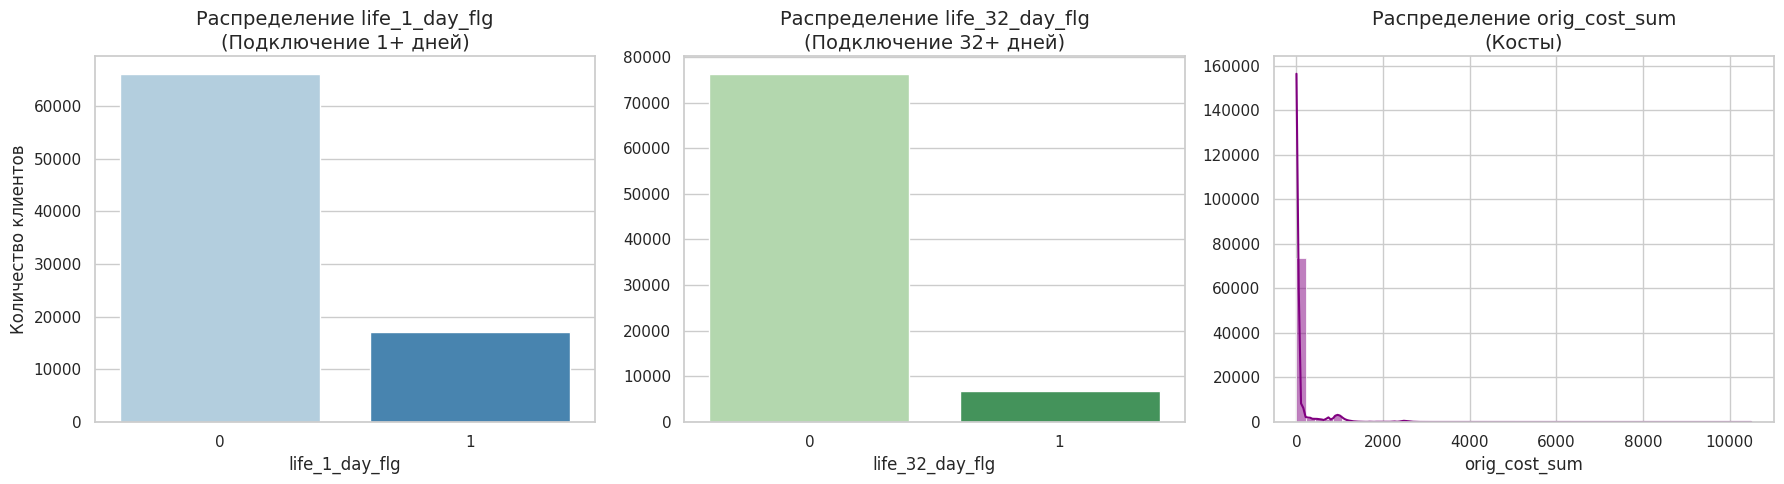

Конверсия в 'Премиум 1+ день': 20.53%
Конверсия в 'Премиум 32+ дня': 8.29%


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: Подключили на 1+ день (флаг)
sns.countplot(data=df_back, x='life_1_day_flg', ax=axes[0], palette='Blues')
axes[0].set_title('Распределение life_1_day_flg\n(Подключение 1+ дней)', fontsize=14)
axes[0].set_ylabel('Количество клиентов')

# График 2: Подключили на 32+ дня (флаг)
sns.countplot(data=df_back, x='life_32_day_flg', ax=axes[1], palette='Greens')
axes[1].set_title('Распределение life_32_day_flg\n(Подключение 32+ дней)', fontsize=14)
axes[1].set_ylabel('')

# График 3: Затраты на клиента (непрерывная метрика)
sns.histplot(data=df_back, x='orig_cost_sum', bins=50, kde=True, ax=axes[2], color='purple')
axes[2].set_title('Распределение orig_cost_sum\n(Косты)', fontsize=14)
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# Посчитаем конверсии
conv_1_day = df_back['life_1_day_flg'].mean() * 100
conv_32_days = df_back['life_32_day_flg'].mean() * 100
print(f"Конверсия в 'Премиум 1+ день': {conv_1_day:.2f}%")
print(f"Конверсия в 'Премиум 32+ дня': {conv_32_days:.2f}%")

## attrition_score а не attririon
## loyalti_score_0

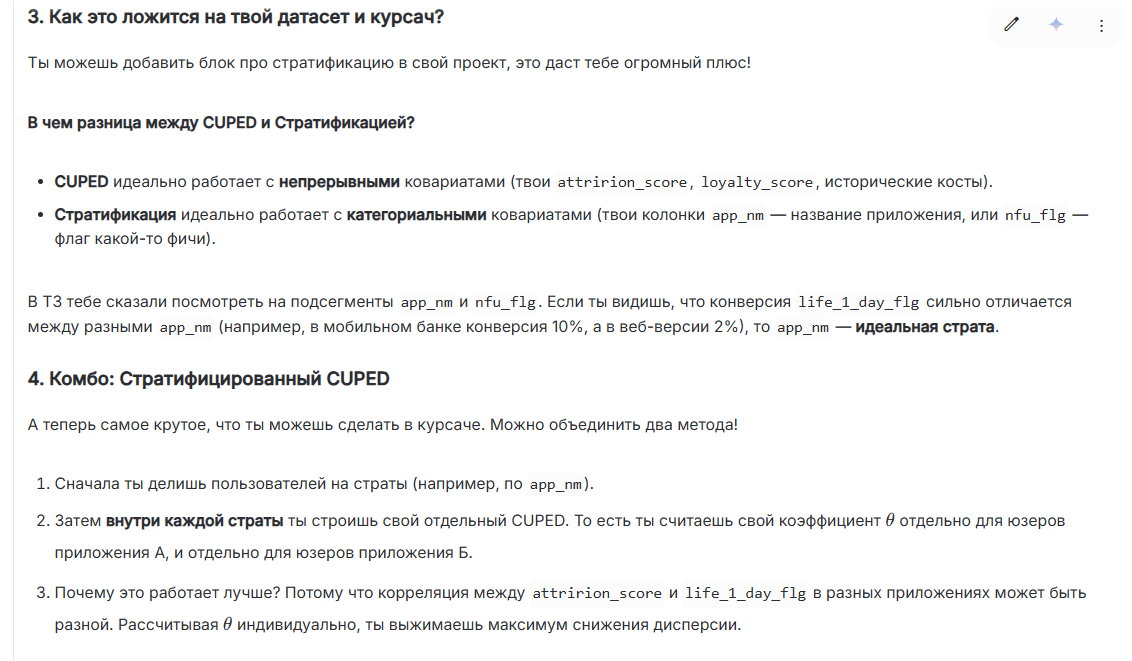

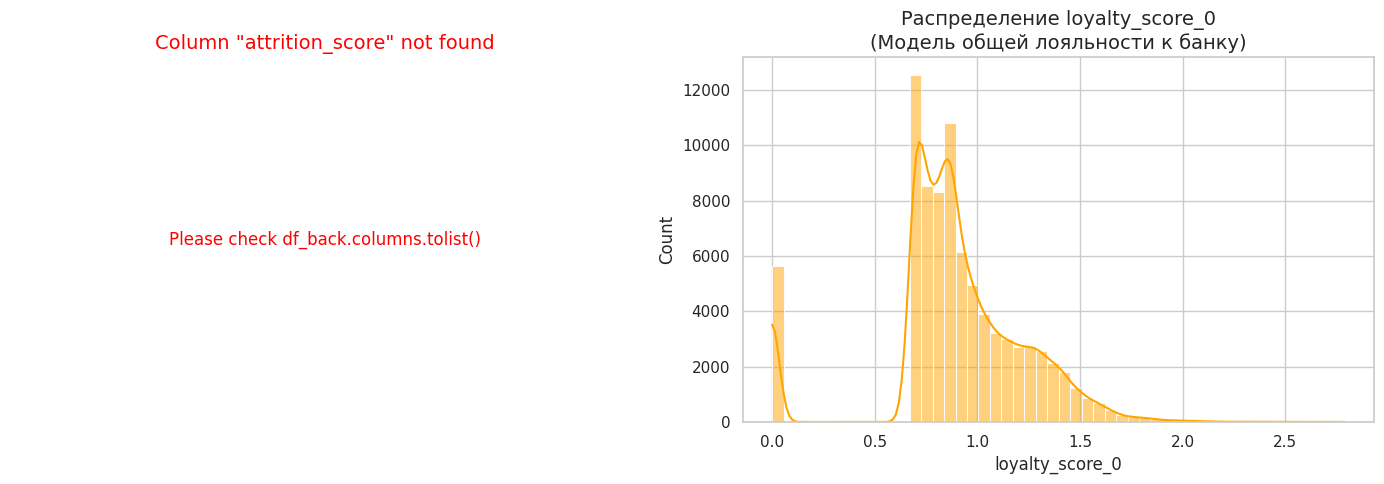

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение attrition_score
# The column 'attrition_score' was not found in the DataFrame.
# Please check the column names (df_back.columns.tolist()) and update this plot with the correct column.
# For now, this subplot will display a message about the missing column.
axes[0].set_title('Column "attrition_score" not found', fontsize=14, color='red')
axes[0].text(0.5, 0.5, 'Please check df_back.columns.tolist()', horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes, color='red', fontsize=12)
axes[0].axis('off') # Hide axes ticks and labels

# Распределение loyalty_score
# Based on available columns, using 'loyalty_score_0'.
sns.histplot(df_back['loyalty_score_0'], bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Распределение loyalty_score_0\n(Модель общей лояльности к банку)', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
print(df_back.columns.tolist() == 'loyalty_score_0')

False


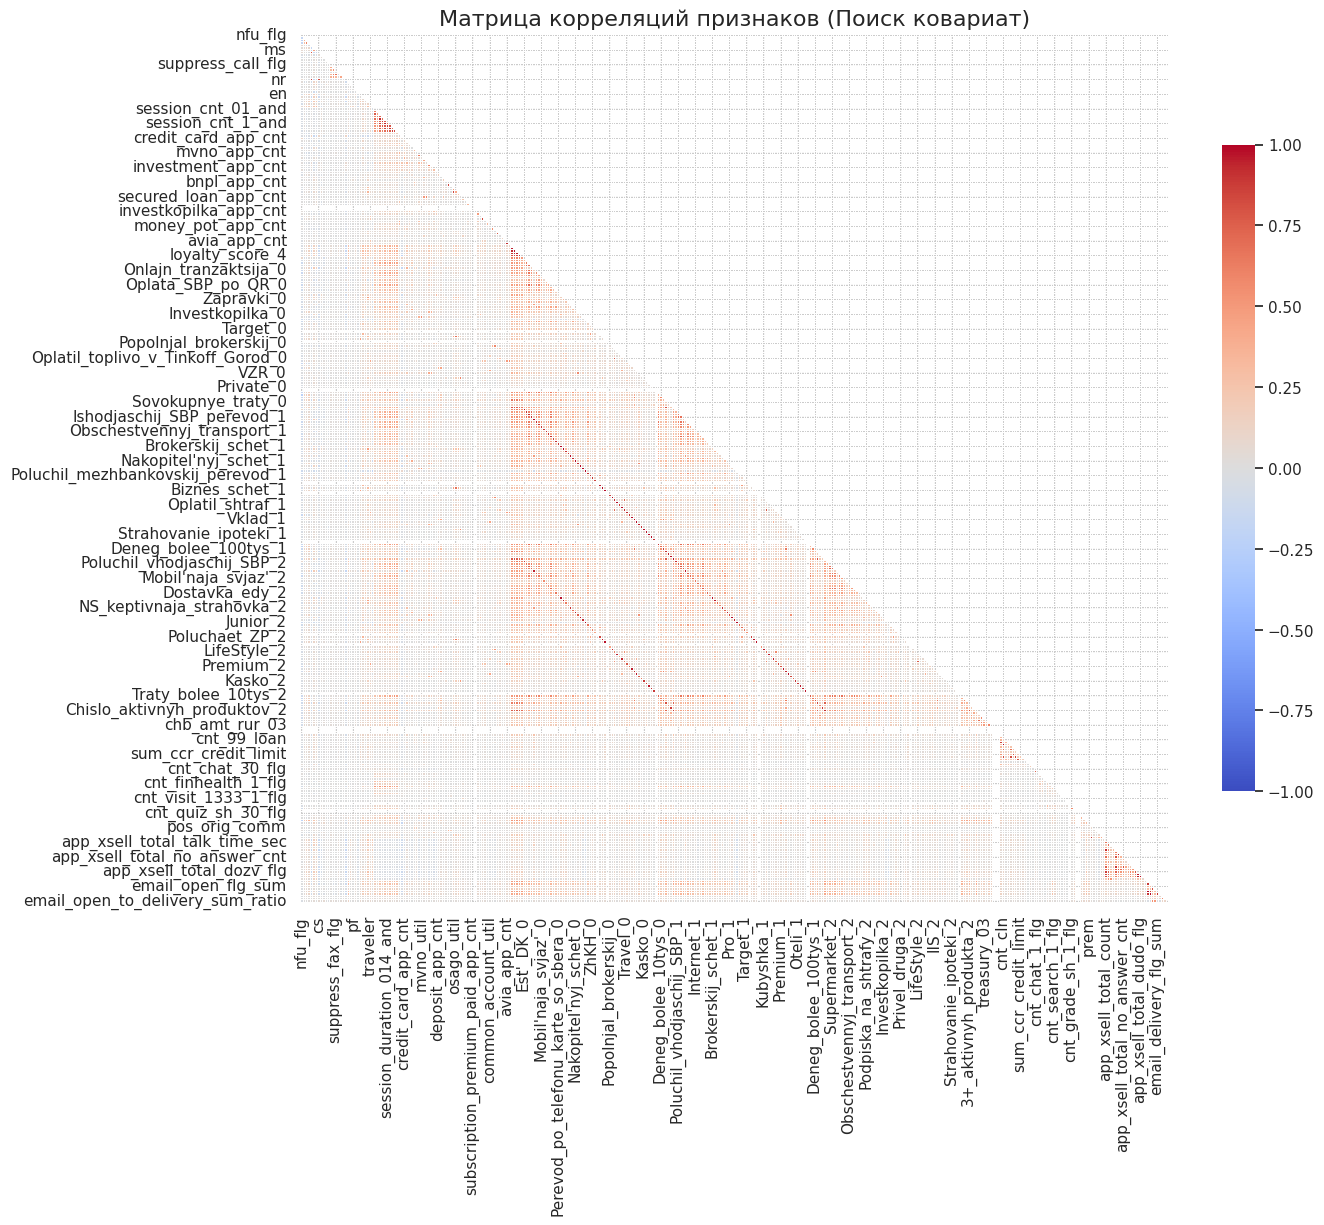

ТОП-10 лучших ковариат для метрики life_1_day_flg (по модулю корреляции Пирсона):
life_32_day_flg             0.591361
orig_cost_sum               0.354612
attrition_score             0.296696
ag                          0.231775
nfu_flg                     0.214999
Deneg_bolee_10tys_0         0.178948
Deneg_bolee_10tys_1         0.165712
Deneg_bolee_10tys_2         0.164831
app_xsell_total_dozv_flg    0.149681
app_xsell_total_dudo_flg    0.146423
Name: life_1_day_flg, dtype: float64


In [ ]:
# Оставляем только числовые колонки для подсчета корреляции
numeric_cols = df_back.select_dtypes(include=[np.number]).columns
corr_matrix = df_back[numeric_cols].corr()

# Строим тепловую карту (Heatmap)
plt.figure(figsize=(14, 12))

# Создаем маску для скрытия верхней половины матрицы (чтобы не дублировать данные)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Отрисовка
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=.5, cbar_kws={"shrink": .7})

plt.title('Матрица корреляций признаков (Поиск ковариат)', fontsize=16)
plt.show()

# Выводим ТОП-10 признаков, которые сильнее всего коррелируют с нашей главной метрикой (по модулю)
target = 'life_1_day_flg'
top_correlations = corr_matrix[target].drop(target).abs().sort_values(ascending=False).head(10)

print(f"ТОП-10 лучших ковариат для метрики {target} (по модулю корреляции Пирсона):")
print(top_correlations)

In [ ]:
target = 'life_1_day_flg'
top_correlations = corr_matrix[target].drop(target).abs().sort_values(ascending=False).head(20)

print(f"ТОП-10 лучших ковариат для метрики {target} (по модулю корреляции Пирсона):")
print(top_correlations)

ТОП-10 лучших ковариат для метрики life_1_day_flg (по модулю корреляции Пирсона):
life_32_day_flg                0.591361
orig_cost_sum                  0.354612
attrition_score                0.296696
ag                             0.231775
nfu_flg                        0.214999
Deneg_bolee_10tys_0            0.178948
Deneg_bolee_10tys_1            0.165712
Deneg_bolee_10tys_2            0.164831
app_xsell_total_dozv_flg       0.149681
app_xsell_total_dudo_flg       0.146423
auto                           0.144916
en                             0.143895
app_xsell_total_reject_flg     0.143337
app_xsell_total_count          0.140585
Chislo_aktivnyh_produktov_0    0.136912
Deneg_bolee_100tys_0           0.136107
3+_aktivnyh_produkta_0         0.133810
Chislo_aktivnyh_produktov_1    0.133252
3+_aktivnyh_produkta_1         0.129625
Deneg_bolee_100tys_2           0.128916
Name: life_1_day_flg, dtype: float64


/tmp/ipykernel_9122/2883991014.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_back, x='nfu_flg', y='life_1_day_flg', errorbar=None, palette='Set1')


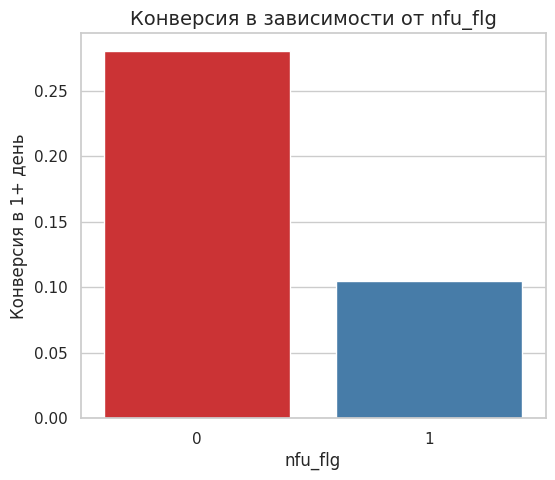

In [ ]:
# Анализ по app_nm (если это текстовая колонка)
if 'app_nm' in df_back.columns:
    plt.figure(figsize=(10, 5))
    # ci=None убирает усы доверительного интервала для ускорения отрисовки
    sns.barplot(data=df_back, x='app_nm', y='life_1_day_flg', errorbar=None, palette='Set2')
    plt.title('Доля полезных подключений (life_1_day_flg) в зависимости от app_nm', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Конверсия в 1+ день')
    plt.show()

# Анализ по nfu_flg (New features usage flag - например)
if 'nfu_flg' in df_back.columns:
    plt.figure(figsize=(6, 5))
    sns.barplot(data=df_back, x='nfu_flg', y='life_1_day_flg', errorbar=None, palette='Set1')
    plt.title('Конверсия в зависимости от nfu_flg', fontsize=14)
    plt.ylabel('Конверсия в 1+ день')
    plt.show()

Хотим снизить дисперсию у вот этих:


```
life_1_day_flg,Наш таргет,"Факт того, что клиент остался на сервисе минимум 1 день (бинарная)"
life_32_day_flg,Наш таргет 2,"Факт того, что клиент остался на сервисе минимум 32 день (бинарная)"
orig_cost_sum,Наш таргет 3,Косты нашего процесса (непрерывная)
```


In [ ]:
df_back['life_1_day_flg']

,life_1_day_flg
0,0
1,0
2,0
3,1
4,0
...,...
83203,0
83204,0
83205,0
83206,0


In [ ]:
print(f'life_1_day_flg ---> {np.var(df_back['life_1_day_flg'])}')

life_1_day_flg ---> 0.16316180955263457


In [ ]:
df_back['life_32_day_flg']

,life_32_day_flg
0,0
1,0
2,0
3,1
4,0
...,...
83203,0
83204,0
83205,0
83206,0


In [ ]:
print(f'variance_life_32_day_flg ---> {np.var(df_back['life_32_day_flg'])}')

variance_life_32_day_flg ---> 0.07599808176098444


In [ ]:
df_back['orig_cost_sum']

,orig_cost_sum
0,0.00
1,0.00
2,0.00
3,0.00
4,1021.11
...,...
83203,0.00
83204,841.76
83205,0.00
83206,0.00


In [ ]:
print(f'orig_cost_sum ---> {np.sqrt(np.var(df_back['orig_cost_sum']))}')

orig_cost_sum ---> 362.70384485391423


In [ ]:
np.mean(df['orig_cost_sum'])

np.float64(112.37214775021633)

отбор ковариат


In [ ]:

# Предполагаем, что df_back уже загружен и очищен
target = 'life_1_day_flg'
# Исключаем айдишники и таргеты из поиска
exclude = ['client_id', target, 'life_32_day_flg', 'orig_cost_sum', 'app_nm', 'nfu_flg']
potential_covariates = [col for col in df_back.select_dtypes(include=np.number).columns if col not in exclude]

# 1. Считаем модуль корреляции всех фичей с таргетом
corr_with_target = df_back[potential_covariates + [target]].corr()[target].drop(target).abs()

# 2. Оставляем только те, где корреляция хотя бы > 0.05 (иначе смысла нет)
good_covariates = corr_with_target[corr_with_target > 0.05].sort_values(ascending=False)
print("Кандидаты в ковариаты по убыванию силы:")
print(good_covariates)

# 3. Как отобрать для Multi-CUPED (убираем дублирующуюся инфу)
selected_multi_covariates = []
for col in good_covariates.index:
    if not selected_multi_covariates:
        selected_multi_covariates.append(col)
    else:
        # Проверяем корреляцию кандидата с уже выбранными фичами
        is_independent = True
        for selected in selected_multi_covariates:
            corr_between = abs(df_back[col].corr(df_back[selected]))
            if corr_between > 0.7:  # Порог коллинеарности (обычно 0.6 - 0.8)
                is_independent = False
                break
        if is_independent:
            selected_multi_covariates.append(col)

print(f"Отобранные фичи для Multi-CUPED: {selected_multi_covariates}")

Кандидаты в ковариаты по убыванию силы:
attrition_score        0.296696
ag                     0.231775
Deneg_bolee_10tys_0    0.178948
Deneg_bolee_10tys_1    0.165712
Deneg_bolee_10tys_2    0.164831
                         ...   
Brokerskij_schet_1     0.052040
Brokerskij_schet_0     0.051572
email_open_flg_sum     0.050881
Target_1               0.050800
Sovokupnye_traty_2     0.050228
Name: life_1_day_flg, Length: 108, dtype: float64
Отобранные фичи для Multi-CUPED: ['attrition_score', 'ag', 'Deneg_bolee_10tys_0', 'Deneg_bolee_10tys_2', 'app_xsell_total_dozv_flg', 'auto', 'en', 'Chislo_aktivnyh_produktov_0', 'Deneg_bolee_100tys_0', 'Pro_0', 'Traty_bolee_10tys_0', 'email_delivery_flg_sum', 'Kreditnyj_produkt_0', 'Zapravki_0', 'app_xsell_total_reject_to_listen_flg', 'Vklad_0', 'el', 'traveler', 'Premium_0', 'Zapravki_2', 'app_xsell_total_nedozv_flg', 'Podpiska_na_shtrafy_0', 'Biznes_schet_0', 'app_xsell_avg_talk_time_sec', 'Junior_2', 'NS_keptivnaja_strahovka_1', 'app_xsell_total_cal

отбор страт


In [ ]:
def evaluate_strata(df, target_col, strata_col):
    # Глобальная дисперсия до стратификации
    var_total = df[target_col].var()
    total_len = len(df)

    # Считаем доли (веса) каждой страты и дисперсию внутри них
    strata_stats = df.groupby(strata_col)[target_col].agg(['var', 'count', 'mean'])
    strata_stats['weight'] = strata_stats['count'] / total_len

    # Если внутри страты всего 1 элемент, var будет NaN, заполним нулем
    strata_stats['var'] = strata_stats['var'].fillna(0)

    # Взвешенная сумма внутригрупповых дисперсий
    var_stratified = (strata_stats['weight'] * strata_stats['var']).sum()

    # Считаем процент снижения дисперсии
    var_reduction = (1 - var_stratified / var_total) * 100

    print(f"--- Оценка страты: {strata_col} ---")
    print(f"Количество уникальных групп: {df[strata_col].nunique()}")
    display(strata_stats)
    print(f"Снижение дисперсии от стратификации: {var_reduction:.2f}%\n")
    return var_reduction

# Проверяем колонки из твоего ТЗ
print("ОЦЕНКА КАНДИДАТОВ В СТРАТЫ:")
# Если app_nm и nfu_flg это категориальные колонки
if 'app_nm' in df_back.columns:
    evaluate_strata(df_back, target, 'app_nm')

if 'nfu_flg' in df_back.columns:
    evaluate_strata(df_back, target, 'nfu_flg')

ОЦЕНКА КАНДИДАТОВ В СТРАТЫ:
--- Оценка страты: nfu_flg ---
Количество уникальных групп: 2


,var,count,mean,weight
nfu_flg,,,,
0,0.201636,47795,0.280071,0.574404
1,0.093523,35413,0.104425,0.425596


Снижение дисперсии от стратификации: 4.62%

